In [1]:
import pickle
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


#### Read the data

In [3]:
filename = "unknown_image_28x28_with_label_dataset_A.pkl"
with open(filename, 'rb') as f:
    image_with_label = pickle.load(f) 

print(image_with_label.keys())

dict_keys(['image', 'label'])


In [ ]:
# You can uncomment the following to sneak into what these images are.
# import random 
# an_unknown_set_of_images = image_with_label['image'].reshape(-1, 28, 28)
# print(an_unknown_set_of_images.shape) 
#
# random_number = random.randint(0, 2195)
# plt.imshow(an_unknown_set_of_images[random_number])

## Principal components in the data with annotated clusters

Let's denote our data `image_with_label["image"]` as $ X \in \mathcal{R}^{n\times m}$ where 784 is the size of feature dimension. 


Let us define the PCA transformation $Q:= [q_1, q_2] \in \mathcal{R}^{2\times n}$. 

We will reduce the dimension of image features from 784 to 2 using PCA by multiplying them with $Q$


$ Z = Q^T X = [q_1, q_2]^T X $ 

Here each of $q_1, q_2$ is the principal component axis. 

Then, the result of the transformation is $Z$, which is the reduced feature data samples $\in \mathcal{R}^{2\times m}$

In [38]:
m,n = image_with_label["image"].shape

print("The number of data samples: %d" % m)
print("The size of feature dimension: %d" % n)

The number of data samples: 2195
The size of feature dimension: 784


Before we apply the PCA, we need to standardize our data. 
This can be done via `StandardScaler()` and its `fit_transform` operation.

In [43]:
scaler = StandardScaler()
image_2d_scaled = scaler.fit_transform(image_with_label["image"])

Now we are ready to apply PCA. 

At first, we declear that we want only two principal component axes for $q_1, q_2$. 

Thus, we use the command `pca = PCA(n_components=2)`

In [42]:
pca = PCA(n_components=2)
data_array_pca = pca.fit_transform(image_2d_scaled)   

`data_array_pca` is the result of the transformation ($Z$), which has the reduced feature dimension.

In [41]:
m_pca ,n_pca = data_array_pca.shape

print("The number of data samples: %d" % m_pca)
print("The size of reduced feature dimension: %d" % n_pca)

The number of data samples: 2195
The size of reduced feature dimension: 2


You can get the PCA transformation $Q:= [q_1, q_2] \in \mathcal{R}^{2\times n}$  from `pca.components_`

In [47]:
pca.components_

array([[-8.45187106e-21,  1.78212588e-21, -7.62961690e-23, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-1.08438851e-17,  5.01282767e-18, -9.47558615e-20, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(2, 784))

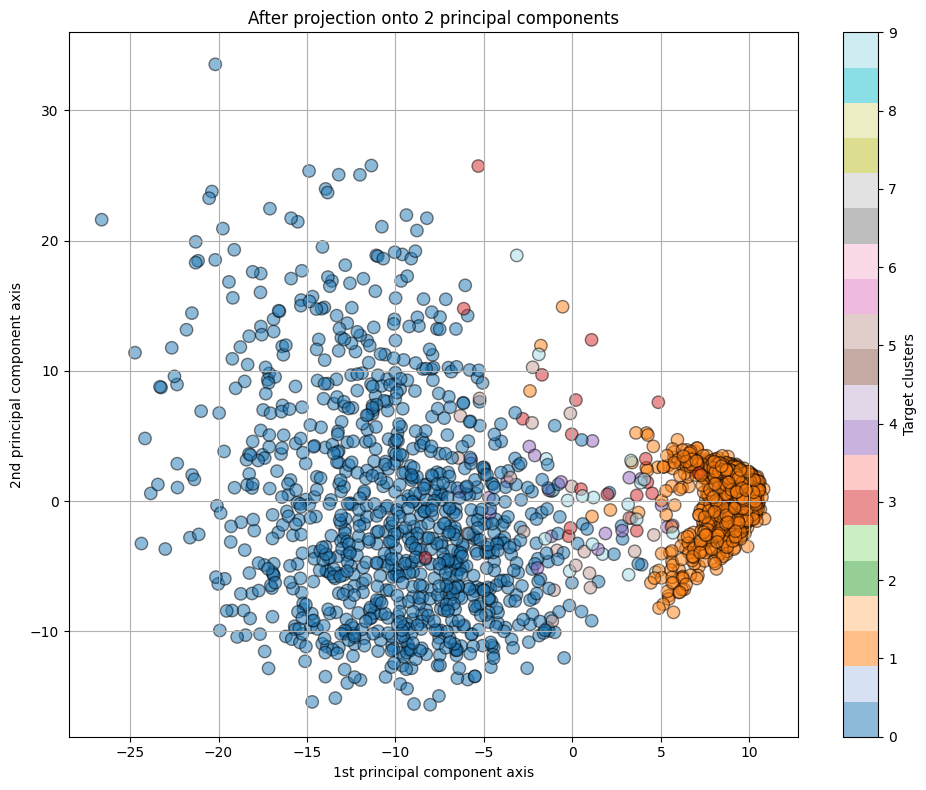

In [44]:
plt.figure(figsize=(10, 8))

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1], c=image_with_label["label"], cmap="tab20", edgecolor='k', s=80, alpha=0.5)
plt.xlabel('1st principal component axis')
plt.ylabel('2nd principal component axis')
plt.title('After projection onto 2 principal components') 

plt.colorbar(label='Target clusters')
plt.grid()
plt.tight_layout()

## Candidate clustering algorithms

1. K-mean algorithm
2. Gaussian mixture model
3. DBSCAN

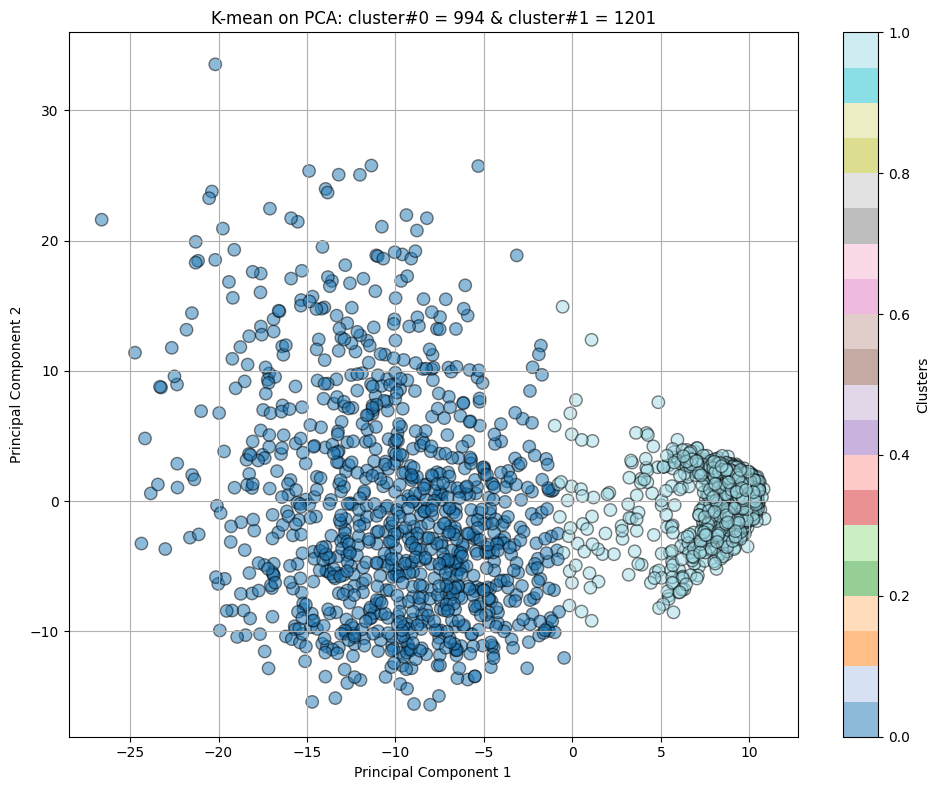

In [9]:
# K-mean algorithm
from sklearn.cluster import KMeans
 
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(data_array_pca)
predicted_cluster =  kmeans.labels_

plt.figure(figsize=(10, 8))

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1],  c=predicted_cluster, edgecolor='k', cmap="tab20", s=80, alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-mean on PCA: cluster#0 = %d & cluster#1 = %d' % (sum(predicted_cluster == 0).item(), sum(predicted_cluster == 1).item()))
 

plt.colorbar(label='Clusters')
plt.grid()
plt.tight_layout()

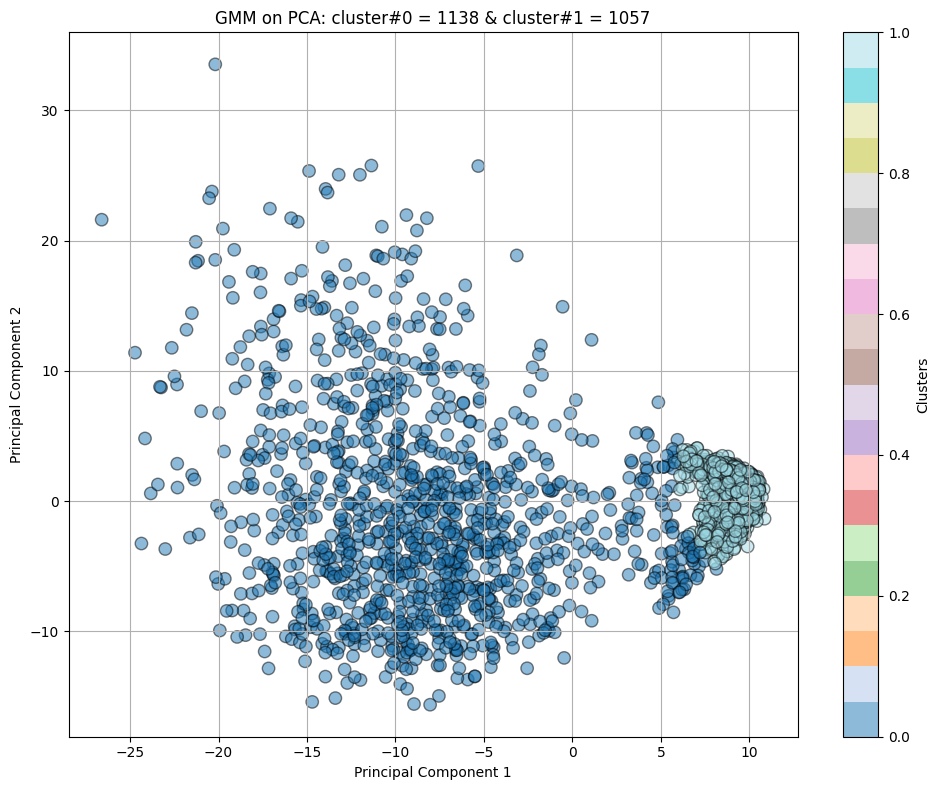

In [8]:
# Gaussian mixture model
from sklearn.mixture import GaussianMixture
X      = data_array_pca
gm = GaussianMixture(n_components=2, random_state=0).fit(X)
predicted_cluster =  gm.predict(X)

plt.figure(figsize=(10, 8))

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1],  c=predicted_cluster, edgecolor='k', cmap="tab20", s=80, alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('GMM on PCA: cluster#0 = %d & cluster#1 = %d' % (sum(predicted_cluster == 0).item(), sum(predicted_cluster == 1).item()))
 

plt.colorbar(label='Clusters')
plt.grid()
plt.tight_layout()

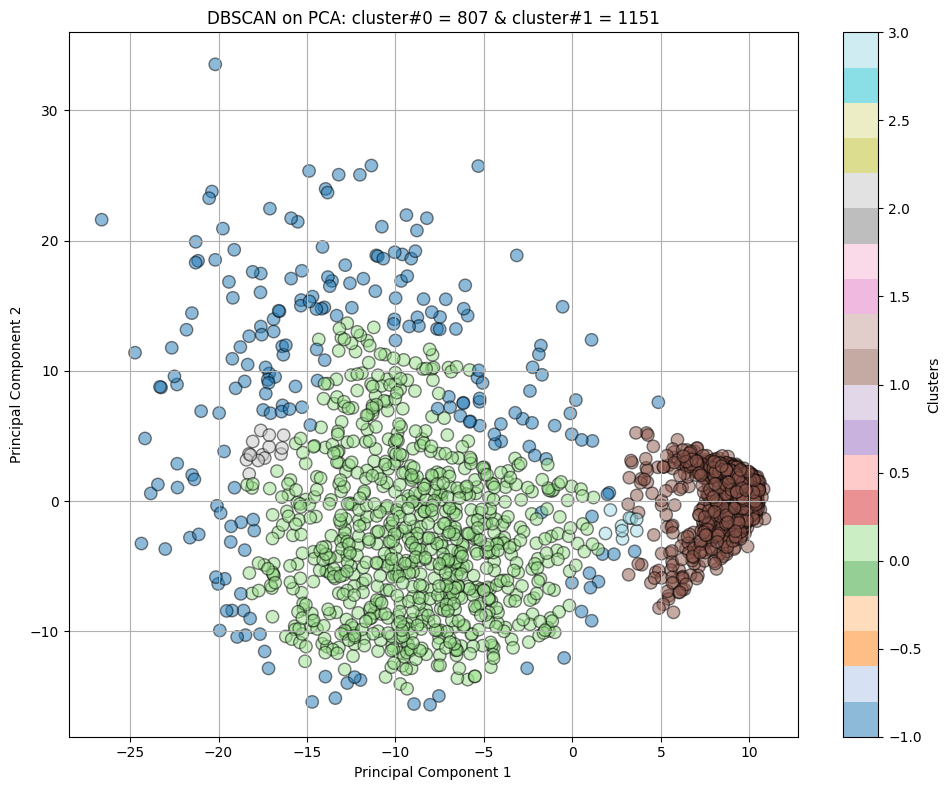

In [7]:
# Gaussian mixture model
from sklearn.cluster import DBSCAN
X      = data_array_pca
dbscan = DBSCAN(eps=1.5, min_samples=10).fit(X)
predicted_cluster =  dbscan.labels_

plt.figure(figsize=(10, 8))

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1],  c=predicted_cluster, cmap="tab20", edgecolor='k', s=80, alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN on PCA: cluster#0 = %d & cluster#1 = %d' % (sum(predicted_cluster == 0).item(), sum(predicted_cluster == 1).item()))
 
plt.colorbar(label='Clusters')

plt.grid()
plt.tight_layout()